# Set up and get latest Launches
Docs: https://github.com/r-spacex/SpaceX-API/tree/master/docs#rspacex-api-docs

In [1]:
import requests
import pandas as pd

# SpaceX API endpoint (example: latest launch)
api_url = "https://api.spacexdata.com/v4/launches/latest"

# Make the API request
response = requests.get(api_url)

# Check if the request was successful
if response.status_code == 200:
    # Parse the JSON response
    launch_data = response.json()
    
    # Select the data you want to visualize 
    data = {
        'Mission Name': launch_data['name'],
        'Launch Date (UTC)': launch_data['date_utc'],
        # ... (add more data points as needed)
    }
    
    # Create a pandas DataFrame
    df = pd.DataFrame(data, index=[0])

else:
    print("Error fetching data from the API")


/var/folders/y7/sb_c_6kn0bj6pvglhb6ddzrw0000gq/T/ipykernel_46081/3940147477.py:2: DeprecationWarning: 
Pyarrow will become a required dependency of pandas in the next major release of pandas (pandas 3.0),
(to allow more performant data types, such as the Arrow string type, and better interoperability with other libraries)
but was not found to be installed on your system.
If this would cause problems for you,
please provide us feedback at https://github.com/pandas-dev/pandas/issues/54466
        
  import pandas as pd


In [2]:
launch_data

{'fairings': None,
 'links': {'patch': {'small': 'https://images2.imgbox.com/eb/d8/D1Yywp0w_o.png',
   'large': 'https://images2.imgbox.com/33/2e/k6VE4iYl_o.png'},
  'reddit': {'campaign': None,
   'launch': 'https://www.reddit.com/r/spacex/comments/xvm76j/rspacex_crew5_launchcoast_docking_discussion_and/',
   'media': None,
   'recovery': None},
  'flickr': {'small': [], 'original': []},
  'presskit': None,
  'webcast': 'https://youtu.be/5EwW8ZkArL4',
  'youtube_id': '5EwW8ZkArL4',
  'article': None,
  'wikipedia': 'https://en.wikipedia.org/wiki/SpaceX_Crew-5'},
 'static_fire_date_utc': None,
 'static_fire_date_unix': None,
 'net': False,
 'window': None,
 'rocket': '5e9d0d95eda69973a809d1ec',
 'success': True,
 'failures': [],
 'details': None,
 'crew': ['62dd7196202306255024d13c',
  '62dd71c9202306255024d13d',
  '62dd7210202306255024d13e',
  '62dd7253202306255024d13f'],
 'ships': [],
 'capsules': ['617c05591bad2c661a6e2909'],
 'payloads': ['62dd73ed202306255024d145'],
 'launchpad': 

## Crew data

In [5]:
crew_members = launch_data['crew']
crew_menbers_data = []
for crew_member_id in crew_members:
    crew_menber_url = f'https://api.spacexdata.com/v4/crew/{crew_member_id}'
    crew_member_response = requests.get(crew_menber_url)
    crew_member_data = crew_member_response.json()
    crew_menbers_data.append(crew_member_data)

In [6]:
crew_menbers_data

[{'name': 'Nicole Aunapu Mann',
  'agency': 'NASA',
  'image': 'https://i.imgur.com/EW93kmg.png',
  'wikipedia': 'https://en.wikipedia.org/wiki/Nicole_Aunapu_Mann',
  'launches': ['62dd70d5202306255024d139'],
  'status': 'active',
  'id': '62dd7196202306255024d13c'},
 {'name': 'Josh A. Cassada',
  'agency': 'NASA',
  'image': 'https://i.imgur.com/I7FDypC.png',
  'wikipedia': 'https://en.wikipedia.org/wiki/Josh_A._Cassada',
  'launches': ['62dd70d5202306255024d139'],
  'status': 'active',
  'id': '62dd71c9202306255024d13d'},
 {'name': 'Koichi Wakata',
  'agency': 'JAXA',
  'image': 'https://i.imgur.com/X2wnqMT.png',
  'wikipedia': 'https://en.wikipedia.org/wiki/Koichi_Wakata',
  'launches': ['62dd70d5202306255024d139'],
  'status': 'active',
  'id': '62dd7210202306255024d13e'},
 {'name': 'Anna Kikina',
  'agency': 'Roscosmos',
  'image': 'https://i.imgur.com/tKCaih3.png',
  'wikipedia': 'https://en.wikipedia.org/wiki/Anna_Kikina',
  'launches': ['62dd70d5202306255024d139'],
  'status': 

## Payload

In [7]:
payload_endpoint = 'https://api.spacexdata.com/v4/payloads/'

In [9]:
launch_payloads = launch_data['payloads']
launch_payloads


['62dd73ed202306255024d145']

In [10]:
payload_datas = []
for payload_id in launch_payloads:
    payload_url = f'{payload_endpoint}{payload_id}'
    payload_response = requests.get(payload_url)
    payload_data = payload_response.json()
    payload_datas.append(payload_data)

In [11]:
payload_datas

[{'dragon': {'capsule': '617c05591bad2c661a6e2909',
   'mass_returned_kg': None,
   'mass_returned_lbs': None,
   'flight_time_sec': None,
   'manifest': None,
   'water_landing': None,
   'land_landing': None},
  'name': 'Crew-5',
  'type': 'Crew Dragon',
  'reused': False,
  'launch': '62dd70d5202306255024d139',
  'customers': ['NASA (CCtCap)'],
  'norad_ids': [],
  'nationalities': ['United States'],
  'manufacturers': ['SpaceX'],
  'mass_kg': None,
  'mass_lbs': None,
  'orbit': 'ISS',
  'reference_system': 'geocentric',
  'regime': 'low-earth',
  'longitude': None,
  'semi_major_axis_km': None,
  'eccentricity': None,
  'periapsis_km': None,
  'apoapsis_km': None,
  'inclination_deg': None,
  'period_min': None,
  'lifespan_years': None,
  'epoch': None,
  'mean_motion': None,
  'raan': None,
  'arg_of_pericenter': None,
  'mean_anomaly': None,
  'id': '62dd73ed202306255024d145'}]

# Handling Pagination (For Large Datasets)

Some endpoints return a limited number of results per request.  To fetch all data, you might need to handle pagination:

In [16]:
import requests

base_url = "https://api.spacexdata.com/v4/launches"
all_launches = []
page = 1
while page < 100:
    print(f"Fetching data from page {page}")
    response = requests.get(f"{base_url}?page={page}")
    if response.status_code == 200:
        launches = response.json()
        print(f"Fetched {len(launches)} launches")
        if not launches:
            break  # No more launches to fetch
        all_launches.extend(launches)
        page += 1
    else:
        print("Error fetching data")
        break

# Process the `all_launches` list as needed


Fetching data from page 1
Fetched 205 launches
Fetching data from page 2
Fetched 205 launches
Fetching data from page 3
Fetched 205 launches
Fetching data from page 4
Fetched 205 launches
Fetching data from page 5
Fetched 205 launches
Fetching data from page 6
Fetched 205 launches
Fetching data from page 7
Fetched 205 launches
Fetching data from page 8
Fetched 205 launches
Fetching data from page 9
Fetched 205 launches
Fetching data from page 10
Fetched 205 launches
Fetching data from page 11
Fetched 205 launches
Fetching data from page 12
Fetched 205 launches
Fetching data from page 13
Fetched 205 launches
Fetching data from page 14
Fetched 205 launches
Fetching data from page 15
Fetched 205 launches
Fetching data from page 16
Fetched 205 launches
Fetching data from page 17
Fetched 205 launches
Fetching data from page 18
Fetched 205 launches
Fetching data from page 19
Fetched 205 launches
Fetching data from page 20
Fetched 205 launches
Fetching data from page 21
Fetched 205 launches
F

In [17]:
print(f"Total number of launches fetched: {len(all_launches)}")

Total number of launches fetched: 20295


In [19]:
all_launches[0]

{'fairings': {'reused': False,
  'recovery_attempt': False,
  'recovered': False,
  'ships': []},
 'links': {'patch': {'small': 'https://images2.imgbox.com/94/f2/NN6Ph45r_o.png',
   'large': 'https://images2.imgbox.com/5b/02/QcxHUb5V_o.png'},
  'reddit': {'campaign': None,
   'launch': None,
   'media': None,
   'recovery': None},
  'flickr': {'small': [], 'original': []},
  'presskit': None,
  'webcast': 'https://www.youtube.com/watch?v=0a_00nJ_Y88',
  'youtube_id': '0a_00nJ_Y88',
  'article': 'https://www.space.com/2196-spacex-inaugural-falcon-1-rocket-lost-launch.html',
  'wikipedia': 'https://en.wikipedia.org/wiki/DemoSat'},
 'static_fire_date_utc': '2006-03-17T00:00:00.000Z',
 'static_fire_date_unix': 1142553600,
 'net': False,
 'window': 0,
 'rocket': '5e9d0d95eda69955f709d1eb',
 'success': False,
 'failures': [{'time': 33,
   'altitude': None,
   'reason': 'merlin engine failure'}],
 'details': 'Engine failure at 33 seconds and loss of vehicle',
 'crew': [],
 'ships': [],
 'caps

# Graphing some data
## Example 1: Launch Success Rate Over Time

In [20]:
%pip install matplotlib


[notice] A new release of pip is available: 24.0 -> 24.1.1
[notice] To update, run: python3.11 -m pip install --upgrade pip
Note: you may need to restart the kernel to use updated packages.


In [24]:
launch = all_launches[0]
# launch['date_utc'][:4]
launch['success']

False

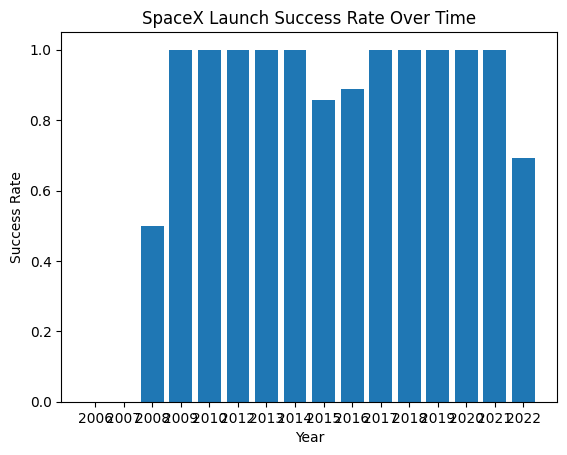

In [25]:
import matplotlib.pyplot as plt
# Extract year and success status from each launch
years = [launch['date_utc'][:4] for launch in all_launches]
successes = [launch['success'] for launch in all_launches]

# Count successful launches per year
success_counts = {}
for year, success in zip(years, successes):
    if year not in success_counts:
        success_counts[year] = {'total': 0, 'successful': 0}
    success_counts[year]['total'] += 1
    if success:
        success_counts[year]['successful'] += 1

# Calculate success rates
success_rates = {year: counts['successful'] / counts['total'] for year, counts in success_counts.items()}

# Create the bar chart
plt.bar(success_rates.keys(), success_rates.values())
plt.xlabel('Year')
plt.ylabel('Success Rate')
plt.title('SpaceX Launch Success Rate Over Time')
plt.show()

### Rotating X-Axis Labels

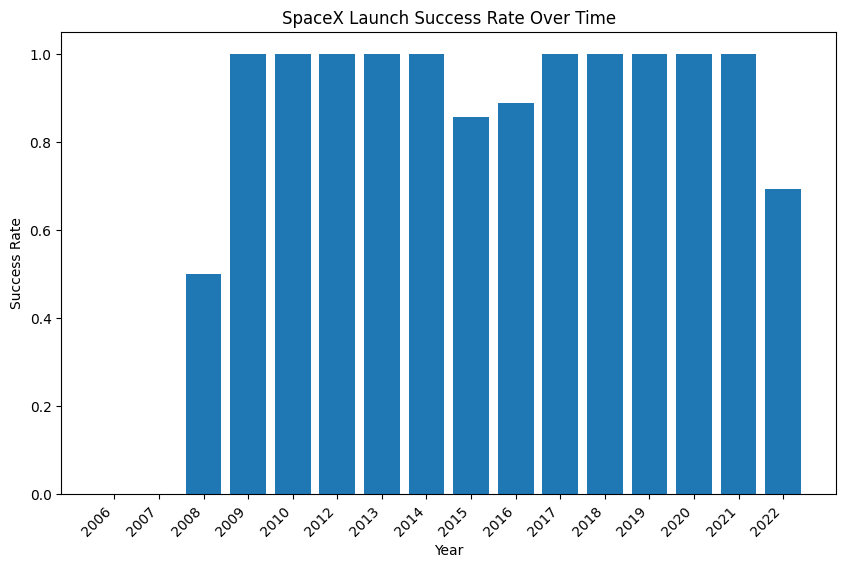

In [26]:
# Create the bar chart
plt.figure(figsize=(10, 6))  # Increase figure size for better label visibility
plt.bar(success_rates.keys(), success_rates.values())
plt.xlabel('Year')
plt.ylabel('Success Rate')
plt.title('SpaceX Launch Success Rate Over Time')
plt.xticks(rotation=45, ha="right")  # Rotate labels by 45 degrees and align right
plt.show()


### Adjusting Spacing Between Bars

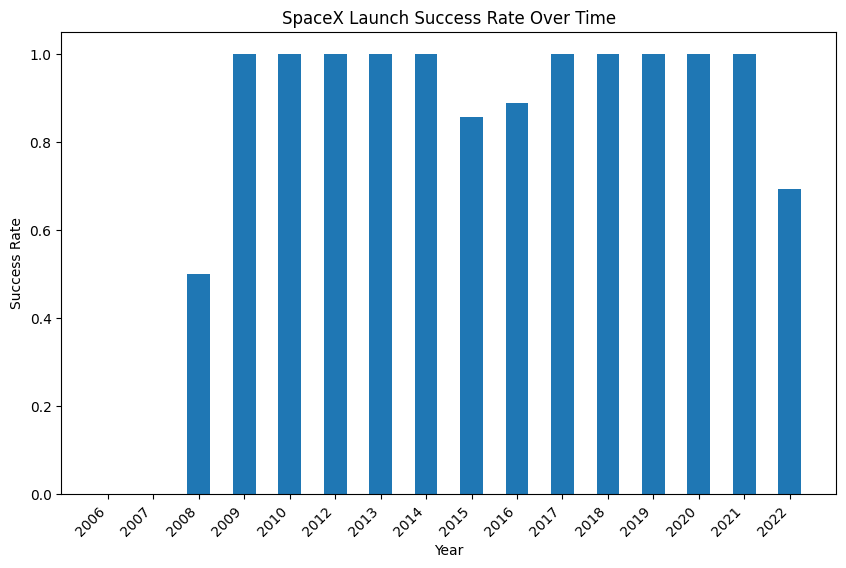

In [30]:
# Create the bar chart
plt.figure(figsize=(10, 6)) 
plt.bar(success_rates.keys(), success_rates.values(), width=0.5)  # Adjust bar width for spacing
plt.xlabel('Year')
plt.ylabel('Success Rate')
plt.title('SpaceX Launch Success Rate Over Time')
plt.xticks(rotation=45, ha="right")
plt.show()


## Example 2: Rocket Reuse Frequency

In [31]:
all_launches[0]

{'fairings': {'reused': False,
  'recovery_attempt': False,
  'recovered': False,
  'ships': []},
 'links': {'patch': {'small': 'https://images2.imgbox.com/94/f2/NN6Ph45r_o.png',
   'large': 'https://images2.imgbox.com/5b/02/QcxHUb5V_o.png'},
  'reddit': {'campaign': None,
   'launch': None,
   'media': None,
   'recovery': None},
  'flickr': {'small': [], 'original': []},
  'presskit': None,
  'webcast': 'https://www.youtube.com/watch?v=0a_00nJ_Y88',
  'youtube_id': '0a_00nJ_Y88',
  'article': 'https://www.space.com/2196-spacex-inaugural-falcon-1-rocket-lost-launch.html',
  'wikipedia': 'https://en.wikipedia.org/wiki/DemoSat'},
 'static_fire_date_utc': '2006-03-17T00:00:00.000Z',
 'static_fire_date_unix': 1142553600,
 'net': False,
 'window': 0,
 'rocket': '5e9d0d95eda69955f709d1eb',
 'success': False,
 'failures': [{'time': 33,
   'altitude': None,
   'reason': 'merlin engine failure'}],
 'details': 'Engine failure at 33 seconds and loss of vehicle',
 'crew': [],
 'ships': [],
 'caps

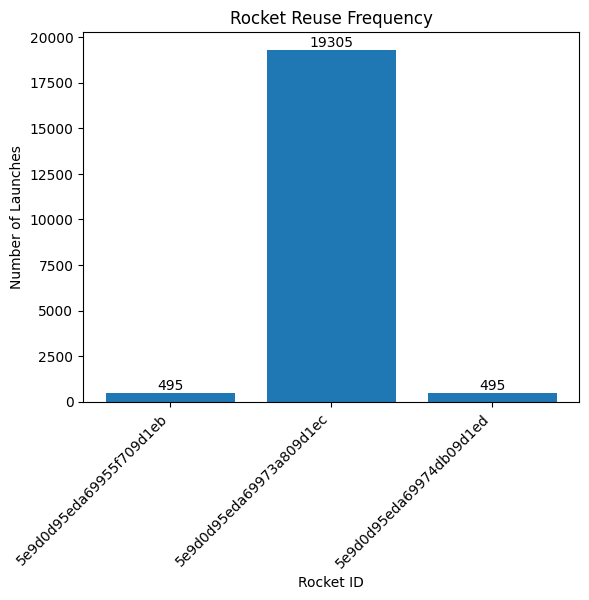

In [39]:
# Extract rocket names and reuse counts
rocket_ids = [launch['rocket'] for launch in all_launches]
rocket_counts = {}
for rocket in rocket_ids:
    if rocket not in rocket_counts:
        rocket_counts[rocket] = 0
    rocket_counts[rocket] += 1
    # rocket_counts[rocket] = rocket_counts.get(rocket, 0) + 1

# Create the bar chart
plt.bar(rocket_counts.keys(), rocket_counts.values())
plt.xlabel('Rocket ID')
plt.ylabel('Number of Launches')
plt.title('Rocket Reuse Frequency')
plt.xticks(rotation=45, ha="right")  # Rotate labels for readability
# display data labels (counts) on top of the bars
for x, y in zip(rocket_counts.keys(), rocket_counts.values()):
    plt.text(x, y, str(y), ha='center', va='bottom')
plt.show()


# Histogram of Launch Cadence (Launches per Month)

In [40]:
import matplotlib.pyplot as plt
from collections import Counter

# Extract month and year from launch dates
launch_months = [launch['date_utc'][:7] for launch in all_launches]

# Count launches per month
launch_counts = Counter(launch_months)
launch_counts

Counter({'2022-11': 891,
         '2022-04': 594,
         '2022-07': 594,
         '2022-08': 594,
         '2022-12': 594,
         '2021-12': 495,
         '2022-05': 495,
         '2022-06': 495,
         '2020-11': 396,
         '2021-03': 396,
         '2021-05': 396,
         '2021-06': 396,
         '2022-01': 396,
         '2022-02': 396,
         '2022-09': 396,
         '2022-10': 396,
         '2017-06': 297,
         '2017-10': 297,
         '2018-12': 297,
         '2020-01': 297,
         '2020-06': 297,
         '2020-08': 297,
         '2020-10': 297,
         '2020-12': 297,
         '2021-01': 297,
         '2021-04': 297,
         '2021-11': 297,
         '2022-03': 297,
         '2014-09': 198,
         '2015-04': 198,
         '2016-05': 198,
         '2017-03': 198,
         '2017-05': 198,
         '2017-08': 198,
         '2017-12': 198,
         '2018-01': 198,
         '2018-02': 198,
         '2018-03': 198,
         '2018-04': 198,
         '2018-05': 198,


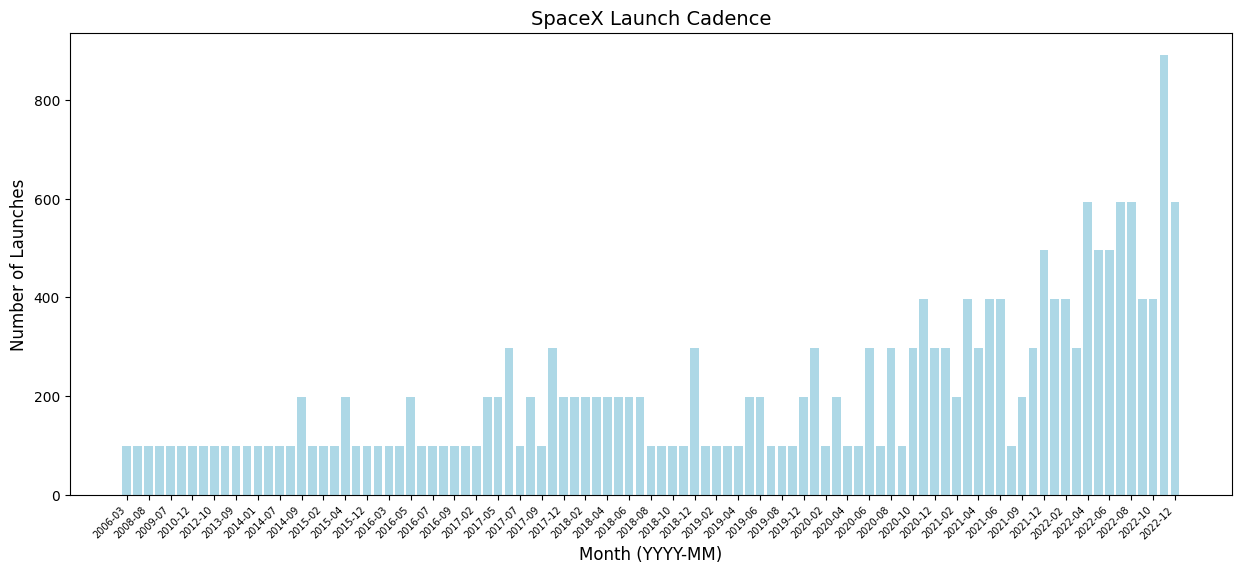

In [50]:


# Create the histogram
plt.figure(figsize=(15, 6))
plt.bar(launch_counts.keys(), launch_counts.values(), color='lightblue')
ax = plt.gca()  # Get the current axes
ax.set_xticks(ax.get_xticks()[::2])
plt.xlabel('Month (YYYY-MM)', fontsize=12)
plt.ylabel('Number of Launches', fontsize=12)
plt.title('SpaceX Launch Cadence', fontsize=14)
plt.xticks(rotation=45, ha="right", fontsize=7)
plt.yticks(fontsize=10)
plt.show()


### Adjust x-ticks for better readability

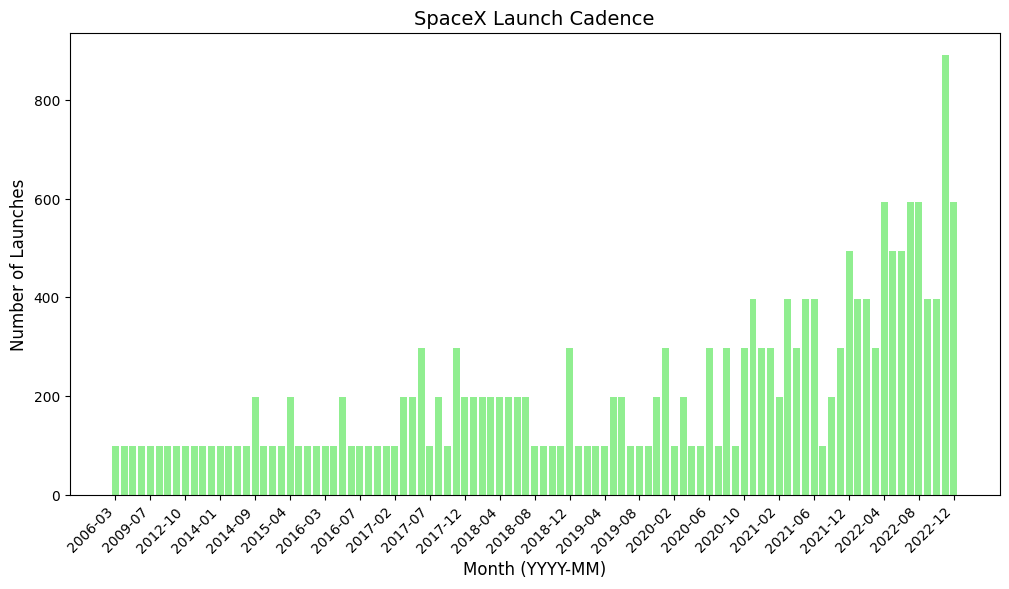

In [37]:
# Create the histogram
plt.figure(figsize=(12, 6))
plt.bar(launch_counts.keys(), launch_counts.values(), color='lightgreen')
plt.xlabel('Month (YYYY-MM)', fontsize=12)
plt.ylabel('Number of Launches', fontsize=12)
plt.title('SpaceX Launch Cadence', fontsize=14)

# Adjust x-ticks for better readability
ax = plt.gca()  # Get the current axes
ax.set_xticks(ax.get_xticks()[::4])  # Select every other tick (adjust the step as needed)
plt.xticks(rotation=45, ha="right", fontsize=10)
plt.yticks(fontsize=10)
plt.show()
